# S4. Does an ECM channel help? — 11-channel screen, 200 epochs

Two runs, `ecm_fov96` and `ecm_fov128`, identical to the final sweep except that the
raster carries an **11th channel holding the PhysiCell ECM initial condition**.

### The encoding

ECM is not a cell. It is a *continuum substrate* — a scalar field PhysiCell/BioFVM holds
on a Cartesian voxel mesh, seeded from `<ROI>_ecm_scaled.csv`, at a **20 µm lattice**.
Cells are agents at measured positions; matrix is a value at a lattice site. They live on
different supports, so they enter the AnnData as different **rows**:

| | rows | channels 0–9 | channel 10 |
|---|---|---|---|
| cell | one per segmented cell, at its measured position | one-hot on its type | 0 |
| ECM | one per 20 µm voxel centre | 0 | `ecm / 10` ∈ [0, 1] |

They are only separate *rows*. After rasterisation there is **one** image of shape
`(11, W, H)` — the model never sees two objects. Splitting the rows is what lets matrix
occupy cell-free space: putting the field onto cell rows instead would discard it exactly
where there are no cells, which in a sparse ROI like JHH317ROI2 is where matrix is
*highest*.

The divisor is 10 because the source CSV is already normalised per ROI to its own 95th
percentile, giving a 0–10 range. **That normalisation is per-ROI, not cohort-global**, so
channel 10 encodes *relative* matrix density within a section, not an absolute quantity
comparable across sections.

### What this notebook can and cannot conclude

Only two runs were trained — ECM arms, no matched no-ECM control at the same 200-epoch
schedule. The comparison here is therefore against the **final-sweep checkpoints**, which
share the ROIs, pixel size, crop geometry, batch size and weight decay but *not* the LR
schedule: their `(0, 100, 900, 1000)` protocol has them at peak LR at epoch 199, while the
ECM runs have fully annealed by then. That confound favours ECM, so a matched-epoch win
alone would not be enough. The trajectory in section 5 is what addresses it.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
# resolve imc_tm from anywhere: repo root, tissuemosaic/, notebooks/, notebooks/archive/
_cands = [c for p in [Path.cwd(), *Path.cwd().parents] for c in (p, p / "tissuemosaic")]
sys.path.insert(0, str(next(c for c in _cands if (c / "imc_tm.py").exists())))
import importlib
import imc_tm
# RE-RUNNING THIS CELL IS NOT ENOUGH ON ITS OWN. Python caches modules in sys.modules,
# so `import imc_tm` in a kernel that already holds it is a no-op and the notebook
# keeps running whatever version of the code the kernel started with.
importlib.reload(imc_tm)
import gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

EPOCH = 199          # last ECM checkpoint; the final sweep has one at the same epoch
MIN_CELLS = 10       # the final sweep's training threshold, applied to BOTH arms
RESULTS = imc_tm.RESULTS_DIR      # result tables sit beside the code, as in prep_imc_spatial/

print(imc_tm.compat_summary())
print("palette:", imc_tm.cluster_palette_source())
# guards the warm-kernel trap above: a stale module returns the old saturated colour
# here and every tissue map in this notebook is silently wrong.
assert to_hex(imc_tm.palette()["other_tissue"]) == "#d8d8d8", "stale imc_tm -- restart the kernel"
print()
print(imc_tm.ecm_status())

tm_compat: 34 numpy types allowlisted (weights_only stays True); relaxed only for test_dataset.pt, train_dataset.pt


palette: colorcet.glasbey_dark



            fov_um  last_epoch  last_loss  periodic_ckpts  latest_ckpt_epoch
name                                                                        
ecm_fov96       96         199      1.100               8                199
ecm_fov128     128         199      0.634               8                199
ecm_fov192     192         199      0.244               8                199


## 1. The encoding, verified on the actual raster

Not "the config says 11 channels" — the SparseImage the model was fed.

In [2]:
import anndata as ad_

spec128 = [s for s in imc_tm.ECM_SWEEP if s["fov_um"] == 128][0]
cfg_ecm128 = imc_tm.ecm_config_dict(spec128)
dm_probe = imc_tm.make_datamodule(cfg_ecm128)
probe_roi = imc_tm.FINAL_ROIS[0]

a_probe = ad_.read_h5ad(imc_tm.ecm_h5ad_dir(spec128["name"]) / (probe_roi + ".h5ad"))
sp_probe = dm_probe.anndata_to_sparseimage(a_probe)
idx, val = sp_probe.data.indices(), sp_probe.data.values()

print("ONE image for", probe_roi, "-- shape (C, W, H) =", tuple(sp_probe.data.shape))
print()
print("{:>3s} {:<16s} {:>9s} {:>16s}".format("ch", "channel", "entries", "value range"))
for c, name in enumerate(imc_tm.ECM_CELL_TYPES):
    m = idx[0] == c
    n = int(m.sum())
    rng = "{:.3f}..{:.3f}".format(float(val[m].min()), float(val[m].max())) if n else "-"
    print("{:>3d} {:<16s} {:>9d} {:>16s}".format(c, name, n, rng))
del sp_probe, dm_probe
gc.collect()

/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


[neptune] [warning] NeptuneDeprecationWarning: The 'neptune-client' package has been deprecated and will be removed in the future. Install the 'neptune' package instead. For more, see https://docs-legacy.neptune.ai/setup/upgrading/
[neptune] [warning] NeptuneDeprecationWarning: You're importing the Neptune client library via the deprecated `neptune.new` module, which will be removed in a future release. Import directly from `neptune` instead.


/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


number of elements ---> 11050
mean and median spacing 5.941896094265878, 5.842315227480571


The dense shape of the image is -> torch.Size([11, 581, 581])
ONE image for JHH369ROI1 -- shape (C, W, H) = (11, 581, 581)

 ch channel            entries      value range
  0 CAF                    636     1.000..1.000
  1 apCAF                  789     1.000..1.000
  2 CD4_Tcell              308     1.000..1.000
  3 CD8_Tcell              462     1.000..1.000
  4 epithelial_tumor_class1       114     1.000..1.000
  5 epithelial_tumor_class1_class2        44     1.000..1.000
  6 mesenchymal_tumor_class1       312     1.000..1.000
  7 mesenchymal_tumor_class1_class2        86     1.000..1.000
  8 other_tissue          5016     1.000..2.000
  9 duct_filler            257     1.000..1.000
 10 ecm                   3025     0.019..1.000


/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/tissuemosaic/data/sparse_image.py:166: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1786372143133/work/aten/src/ATen/Context.cpp:816.)
  return torch.sparse_coo_tensor(


36949

Channel 10 is a continuous field; channels 0–9 are one-hot counts. `other_tissue`
reaching 2.0 is two same-type cells landing in the same 2 µm pixel and summing — the
reason `CropperSparseTensor` has an `if torch.any(values < 1.0)` branch at all.

That branch matters here, and **not in the direction the config comment originally
assumed**. Because every ECM value is < 1, the cropper switches to counting *nonzero
entries* rather than summing cell mass. Matrix alone contributes up to ~23 entries per
96 µm window and ~41 per 128 µm window, so `n_element_min_for_crop = 20` is satisfied by
matrix by itself at 128 µm and needs only a handful of cells at 96 µm. **The ECM arm
therefore trained on a larger, emptier tile set than the 10-channel arm did at threshold
10.** That is a second difference between the arms beyond the extra channel, and it is
why everything below is re-filtered onto a shared grid.

In [3]:
enc = []
for roi in imc_tm.FINAL_ROIS:
    a = ad_.read_h5ad(imc_tm.ecm_h5ad_dir(spec128["name"]) / (roi + ".h5ad"))
    e = np.asarray(a.obsm["cell_type_proportions"])[:, 10]
    is_e = np.asarray(a.obs["is_ecm"].values, dtype=bool)
    enc.append(dict(roi=roi, patient=imc_tm.roi_to_patient(roi),
                    cells=int((~is_e).sum()), ecm_voxels=int(is_e.sum()),
                    ecm_min=float(e[is_e].min()), ecm_mean=float(e[is_e].mean()),
                    ecm_max=float(e[is_e].max())))
ENC = pd.DataFrame(enc)
print(ENC.to_string(index=False))
print()
print("total: {:,} cells + {:,} ECM rows".format(ENC.cells.sum(), ENC.ecm_voxels.sum()))

       roi patient  cells  ecm_voxels  ecm_min  ecm_mean  ecm_max
JHH369ROI1  JHH369   8025        3025 0.019139  0.481915      1.0
JHH369ROI2  JHH369   6383        3025 0.029914  0.591905      1.0
JHH369ROI3  JHH369   7572        3025 0.060685  0.634808      1.0
JHH369ROI4  JHH369   8724        3025 0.046663  0.640675      1.0
JHH387ROI1  JHH387  10597        2500 0.009277  0.534102      1.0
JHH380ROI1  JHH380   8250        2500 0.016726  0.603594      1.0
JHH357ROI5  JHH357   8920        3025 0.016860  0.418974      1.0
JHH317ROI2  JHH317   2632        2500 0.002747  0.658800      1.0

total: 61,103 cells + 22,625 ECM rows


## 2. Training

200 epochs, `warm_up`/`warm_down` 20/20 — upstream's 10/80/10 *shape*, compressed to a
short run. Both finished; neither collapsed.

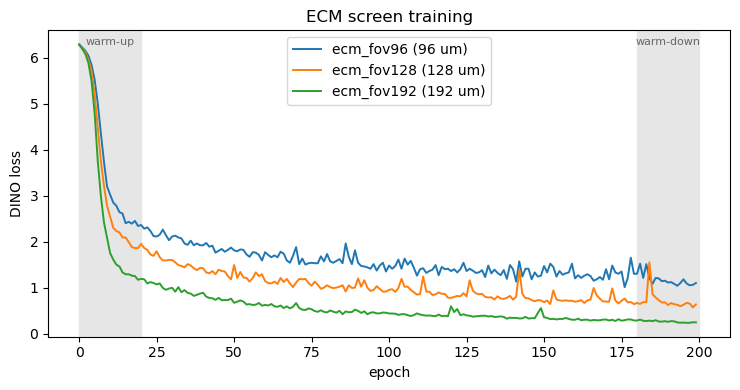

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4))
for spec in imc_tm.ECM_SWEEP:
    lc = imc_tm.read_loss_curve(spec["name"], root=imc_tm.ECM_RUN_DIR)
    ax.plot(lc["epoch"], lc["loss"], lw=1.4, label="{} ({} um)".format(spec["name"], spec["fov_um"]))
ax.axvspan(0, 20, color="0.9", zorder=0)
ax.axvspan(180, 200, color="0.9", zorder=0)
ax.text(10, ax.get_ylim()[1] * 0.95, "warm-up", ha="center", fontsize=8, color="0.4")
ax.text(190, ax.get_ylim()[1] * 0.95, "warm-down", ha="center", fontsize=8, color="0.4")
ax.set_xlabel("epoch"); ax.set_ylabel("DINO loss"); ax.legend(); ax.set_title("ECM screen training")
plt.tight_layout(); plt.show()

The 128 µm run sits below the 96 µm run throughout. **That is not evidence it is better.**
DINO loss magnitude depends on how hard the multi-crop task is, and the crop geometry
differs between the two, so the two curves are not on a common scale. Only the metrics
below compare them.

## 3. Featurisation on a shared grid

Four models: the two ECM runs at epoch 199, and the two final-sweep runs at the same
epoch. All four are tiled with `n_element_min_for_crop = 1` so **nothing is culled at
featurisation time** — the candidate grid depends only on `global_size` and the seeded
tiling origin, so the ECM and base grids for a given FOV are the same set of positions.
The filter is then applied once, identically, to both arms.

In [5]:
def featurize(tag, cfg, ckpt, h5ad_dir, fov_um, kind):
    adatas = imc_tm.load_all_anndata(h5ad_dir)
    dm = imc_tm.make_datamodule(cfg, n_element_min_for_crop=1)
    model = imc_tm.load_model(ckpt)
    r = imc_tm.featurize_windows(model, dm, adatas, frac_overlap=0.0, seed=0, verbose=False)
    r.update(tag=tag, kind=kind, fov_um=fov_um, epoch=EPOCH, ckpt=str(ckpt))
    del model, dm, adatas
    gc.collect(); torch.cuda.empty_cache()
    print("  {:<13s} {:5d} windows, features {}".format(tag, len(r["roi"]), r["features"].shape))
    return r

# Pinned, NOT `for spec in imc_tm.ECM_SWEEP`. This notebook's design is a matched-epoch
# comparison against a no-ECM counterpart, and only these two have one -- there is no
# final_fov192. A third ECM config is a FOV question, not a channel question, and belongs
# in S4b's qualitative comparison rather than here.
ECM_ARMS = ["ecm_fov96", "ecm_fov128"]

RES = {}
for spec in [s for s in imc_tm.ECM_SWEEP if s["name"] in ECM_ARMS]:
    RES[spec["name"]] = featurize(spec["name"], imc_tm.ecm_config_dict(spec),
                                  imc_tm.ecm_checkpoint(spec["name"], EPOCH),
                                  imc_tm.ecm_h5ad_dir(spec["name"]), spec["fov_um"], "ecm")
for spec in imc_tm.FINAL_SWEEP:
    RES[spec["name"]] = featurize(spec["name"], imc_tm.final_config_dict(spec),
                                  imc_tm.final_checkpoint(spec["name"], EPOCH),
                                  imc_tm.final_h5ad_dir(spec["name"]), spec["fov_um"], "base")

/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/pl_bolts/__init__.py:11: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(numpy, tp_name):
/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/pl_bolts/__init__.py:11: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(numpy, tp_name):
/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:34: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  "lr_options": generate_power_seq(LEARNING_RATE_CIFAR, 11),
/home/g

/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


number of elements ---> 5132
mean and median spacing 9.040660615080185, 7.006655558763179
The dense shape of the image is -> torch.Size([11, 530, 530])


number of elements ---> 11945
mean and median spacing 5.726177635707582, 5.503164345211142
The dense shape of the image is -> torch.Size([11, 580, 580])


...

number of elements ---> 7572
mean and median spacing 6.975763445255431, 6.472262341392154
The dense shape of the image is -> torch.Size([10, 581, 581])


number of elements ---> 8724
mean and median spacing 6.807801972872951, 6.434931372051974
The dense shape of the image is -> torch.Size([10, 580, 581])


number of elements ---> 8250
mean and median spacing 6.682641894353679, 6.308046216872109
The dense shape of the image is -> torch.Size([10, 530, 531])


number of elements ---> 10597
mean and median spacing 5.94761912150776, 5.836300547191762
The dense shape of the image is -> torch.Size([10, 530, 532])


  final_fov128    700 windows, features (700, 512)


In [6]:
# The base grid is the reference: it is a strict subset of the ECM grid, because a tile
# holding matrix but no cells exists only in the 11-channel raster.
DAT = {}
for fov in (96, 128):
    base, ecm = RES["final_fov%d" % fov], RES["ecm_fov%d" % fov]
    idx = imc_tm.align_to_grid(base, ecm)          # raises if the grids disagree
    keep = base["n_cells"] >= MIN_CELLS
    DAT[fov] = dict(
        fov=fov, n_grid=len(base["roi"]), n_kept=int(keep.sum()),
        roi=base["roi"][keep], centers=base["centers_um"][keep],
        n_cells=base["n_cells"][keep], n_ecm=ecm["n_ecm"][idx][keep],
        n_ecm_voxels=ecm["n_ecm_voxels"][idx][keep],
        comp10=base["composition"][keep], comp11=ecm["composition"][idx][keep],
        feat_base=base["features"][keep], feat_ecm=ecm["features"][idx][keep])
    # proof, not assumption: the two arms are indexed to the same physical windows
    worst = np.abs(base["centers_um"][keep] - ecm["centers_um"][idx][keep]).max()
    worst_n = np.abs(base["n_cells"][keep] - ecm["n_cells"][idx][keep]).max()
    print("fov{:3d}  grid {} -> {} windows with >={} cells | "
          "max centre disagreement {:.3g} um, max cell-count disagreement {:.3g}".format(
              fov, DAT[fov]["n_grid"], DAT[fov]["n_kept"], MIN_CELLS, worst, worst_n))
    assert worst == 0.0 and worst_n == 0.0, "grids are not the same windows"
print()
print("ECM per window (sum of channel 10):")
for fov, d in DAT.items():
    print("  fov{:3d}  min {:.2f}  median {:.2f}  max {:.2f}".format(
        fov, d["n_ecm"].min(), np.median(d["n_ecm"]), d["n_ecm"].max()))

fov 96  grid 1161 -> 1053 windows with >=10 cells | max centre disagreement 0 um, max cell-count disagreement 0
fov128  grid 700 -> 637 windows with >=10 cells | max centre disagreement 0 um, max cell-count disagreement 0

ECM per window (sum of channel 10):
  fov 96  min 0.00  median 12.15  max 23.54
  fov128  min 0.00  median 20.19  max 41.33


## 4. Metrics

`kappa` is the share of the available headroom above chance that neighbouring windows
share a cluster: a probability difference, so unlike `z` it does not inflate with window
count. Because both arms are now on **the same grid with the same number of windows**,
raw kappa is directly comparable within a FOV — but it is still reported as a **gain over
the 10-channel composition baseline**, so a config only scores by beating what you would
get from counting cell types in the same windows.

The baseline is deliberately the **same** for both arms: the 10-channel composition. Using
each arm's own baseline would let the 11-dimensional version absorb precisely the matrix
signal the comparison is asking about. That 11-dim baseline is reported separately, as
`comp11`, to show how much of the ECM channel is trivially recoverable without a model.

### An upstream seeding bug had to be fixed first

The first version of this analysis was **not reproducible**: rebuilding the graph on
identical input gave bit-identical kappa for the 512-dimensional DINO features but drew
anywhere in 0.147–0.160 for the 10-channel composition baseline. Since every gain divides
by that baseline, that was a ±4% wobble on every number in a comparison whose smaller
effect is +8%.

The cause is upstream, in `SmartPca.fit` (`tissuemosaic/utils/validation_util.py`), which
regularises the covariance matrix with an **unseeded** draw before taking its SVD:

```python
eps = 1E-4 * torch.randn(p, dtype=cov.dtype, device=cov.device)
cov += torch.diag(eps)
```

Against 512 dimensions of DINO features that jitter is negligible. Against a
10-dimensional composition vector — z-scored, so the covariance diagonal is ~1, with many
near-duplicate windows — it perturbs the retained subspace enough to flip kNN ties, and
the Leiden partition moves with them. `imc_tm.umap_graph` now calls `torch.manual_seed`
before `SmartPca`, which makes every number below reproducible across repeats, call
orders and processes. `N_REPS = 2` below is an assertion that it stayed that way, not an
average.

In [7]:
N_REPS = 2         # a determinism check, not an average -- see above

def evaluate(X, centers, roi, reps=1, resolutions=(0.6, 0.8, 1.0, 1.25, 1.5),
             seeds=(0, 1, 2, 3, 4)):
    # PCA and UMAP are identical across Leiden settings, so build the graph once per rep
    # -- rebuilding it per setting would spend the whole sweep on the embedding.
    out, labels, keep_g = [], {}, None
    for rep in range(reps):
        g = imc_tm.umap_graph(X)
        if keep_g is None:
            keep_g = g
        for res in resolutions:
            for seed in (seeds if res == 1.0 else (0,)):
                lab = imc_tm.leiden_on(g["graph"], resolution=res, seed=seed)
                sc_ = imc_tm.spatial_coherence(centers, roi, lab, k=4, n_perm=200, seed=0)
                if rep == 0:
                    labels[(res, seed)] = lab
                out.append(dict(rep=rep, res=res, seed=seed,
                                n_clusters=len(np.unique(lab)), kappa=sc_["kappa"], z=sc_["z"]))
    return pd.DataFrame(out), labels, keep_g

SWEEP, LAB, EMB = {}, {}, {}
for fov, d in DAT.items():
    for arm, X in (("base", d["feat_base"]), ("ecm", d["feat_ecm"]),
                   ("comp10", d["comp10"]), ("comp11", d["comp11"])):
        df, labels, g = evaluate(X, d["centers"], d["roi"], reps=N_REPS)
        df.insert(0, "arm", arm); df.insert(0, "fov", fov)
        SWEEP[(fov, arm)] = df; LAB[(fov, arm)] = labels; EMB[(fov, arm)] = g
        print("  fov{:3d} {:<7s} kappa {:.4f}".format(
            fov, arm, df.query("res == 1.0 and seed == 0 and rep == 0")["kappa"].iloc[0]))
PS = pd.concat(SWEEP.values(), ignore_index=True)

# every setting must give the same kappa on every rebuild; if this fires, the seeding
# fix in imc_tm.umap_graph has regressed and no number in this notebook is trustworthy
n_unique = PS.groupby(["fov", "arm", "res", "seed"])["kappa"].nunique()
assert (n_unique == 1).all(), "clustering is not reproducible across rebuilds"
print()
print("determinism: {} settings, every rebuild identical".format(len(n_unique)))

/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  fov 96 base    kappa 0.2004


/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  fov128 comp10  kappa 0.1480


/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  fov128 comp11  kappa 0.1845

determinism: 72 settings, every rebuild identical


In [8]:
def at(df, res=1.0, seed=0, rep=0):
    return float(df.query("res == @res and seed == @seed and rep == @rep")["kappa"].iloc[0])

summary = []
for fov, d in DAT.items():
    ref = at(SWEEP[(fov, "comp10")])
    for arm in ("comp10", "comp11", "base", "ecm"):
        df = SWEEP[(fov, arm)]
        k = at(df)
        over_res = df.query("seed == 0 and rep == 0").set_index("res")["kappa"]
        summary.append(dict(
            fov=fov, arm=arm, n_windows=d["n_kept"],
            n_clusters=int(df.query("res == 1.0 and seed == 0 and rep == 0")["n_clusters"].iloc[0]),
            kappa=k,
            sd_over_seeds=float(df.query("res == 1.0 and rep == 0")["kappa"].std()),
            gain=imc_tm.safe_gain(k, ref),
            gain_res_lo=imc_tm.safe_gain(over_res.min(), ref),
            gain_res_hi=imc_tm.safe_gain(over_res.max(), ref)))
HEAD = pd.DataFrame(summary)
HEAD.to_csv(RESULTS / "ecm_headline.csv", index=False)
HEAD.round(4)

,fov,arm,n_windows,n_clusters,kappa,sd_over_seeds,gain,gain_res_lo,gain_res_hi
0,96,comp10,1053,14,0.1584,0.0096,1.0000,0.9090,1.0135
1,96,comp11,1053,15,0.1721,0.0126,1.0862,1.0345,1.2518
2,96,base,1053,15,0.2004,0.0093,1.2652,1.2367,1.6629
3,96,ecm,1053,15,0.2860,0.0083,1.8054,1.5926,2.0410
4,128,comp10,637,14,0.1480,0.0014,1.0000,0.9786,1.1069
5,128,comp11,637,14,0.1845,0.0058,1.2460,1.1622,1.4412
6,128,base,637,15,0.3507,0.0075,2.3691,2.3052,2.5815
7,128,ecm,637,14,0.3795,0.0117,2.5634,2.4819,3.0113


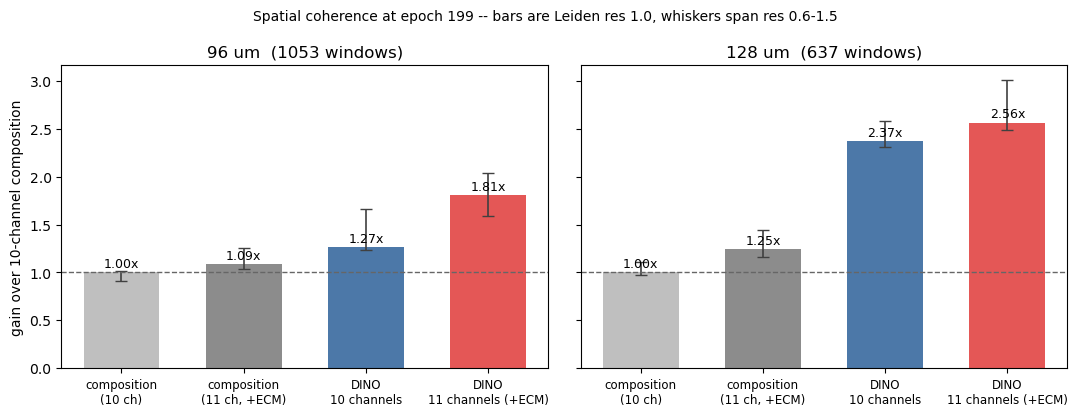

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
order = ["comp10", "comp11", "base", "ecm"]
nice = {"comp10": "composition\n(10 ch)", "comp11": "composition\n(11 ch, +ECM)",
        "base": "DINO\n10 channels", "ecm": "DINO\n11 channels (+ECM)"}
cols = {"comp10": "0.75", "comp11": "0.55", "base": "#4C78A8", "ecm": "#E45756"}
for ax, fov in zip(axes, (96, 128)):
    sub = HEAD.query("fov == @fov").set_index("arm").loc[order]
    xs = np.arange(len(order))
    ax.bar(xs, sub["gain"], color=[cols[a] for a in order], width=0.62)
    lo = (sub["gain"] - sub["gain_res_lo"]).clip(lower=0)
    hi = (sub["gain_res_hi"] - sub["gain"]).clip(lower=0)
    ax.errorbar(xs, sub["gain"], yerr=np.vstack([lo, hi]), fmt="none", ecolor="0.25",
                capsize=4, lw=1.2)
    for x, v in zip(xs, sub["gain"]):
        ax.text(x, v + 0.05, "{:.2f}x".format(v), ha="center", fontsize=9)
    ax.axhline(1.0, color="0.4", lw=1, ls="--")
    ax.set_xticks(xs); ax.set_xticklabels([nice[a] for a in order], fontsize=8.5)
    ax.set_title("{} um  ({} windows)".format(fov, sub["n_windows"].iloc[0]))
axes[0].set_ylabel("gain over 10-channel composition")
fig.suptitle("Spatial coherence at epoch {} -- bars are Leiden res 1.0, whiskers span res 0.6-1.5".format(EPOCH),
             fontsize=10)
plt.tight_layout(); plt.show()

Read the whiskers, not just the bars: they span Leiden resolution 0.6–1.5, which is the
axis these numbers are actually sensitive to. A gap that survives the whole whisker range
is a result; one that does not is a clustering artefact.

## 5. The confound: where does the base model actually get to?

The base checkpoints at epoch 199 are at peak LR — their cosine decay runs 900→1000. So
`base@199` is *not* a converged control, and beating it proves little on its own. This
traces the base model's gain across every periodic checkpoint available, on the same grid,
same filter, same clustering. The question is whether the ECM result sits above the base
model's **whole trajectory**, not just above one badly chosen point on it.

In [10]:
TRAJ_CSV = RESULTS / "ecm_base_trajectory.csv"
EPOCHS = [24, 99, 199, 299, 399, 499, 599, 699]

# The cache stores kappa ONLY. gain is derived below from this notebook's own baseline,
# so a cached trajectory can never be divided by a baseline from some earlier run.
if TRAJ_CSV.is_file():
    TRAJ = pd.read_csv(TRAJ_CSV)
    print("loaded cached", TRAJ_CSV.name, "-- delete it to recompute (~12 min)")
else:
    traj = []
    for spec in imc_tm.FINAL_SWEEP:
        fov = spec["fov_um"]; d = DAT[fov]
        want = imc_tm.window_key(d["roi"], d["centers"])
        adatas = imc_tm.load_all_anndata(imc_tm.final_h5ad_dir(spec["name"]))
        dm = imc_tm.make_datamodule(imc_tm.final_config_dict(spec), n_element_min_for_crop=1)
        have = set(imc_tm.final_periodic_epochs(spec["name"]))
        for ep in EPOCHS:
            if ep not in have:
                continue
            model = imc_tm.load_model(imc_tm.final_checkpoint(spec["name"], ep))
            r = imc_tm.featurize_windows(model, dm, adatas, frac_overlap=0.0, seed=0, verbose=False)
            pos = {k: i for i, k in enumerate(imc_tm.window_key(r["roi"], r["centers_um"]))}
            sel = np.array([pos[k] for k in want])
            lab = imc_tm.leiden_on(imc_tm.umap_graph(r["features"][sel])["graph"],
                                   resolution=1.0, seed=0)
            sc_ = imc_tm.spatial_coherence(d["centers"], d["roi"], lab, k=4, n_perm=200, seed=0)
            traj.append(dict(fov=fov, epoch=ep, n_clusters=len(np.unique(lab)), kappa=sc_["kappa"]))
            print("  fov{:3d} ep{:<4d} kappa {:.4f}".format(fov, ep, sc_["kappa"]), flush=True)
            del model; gc.collect(); torch.cuda.empty_cache()
        del dm, adatas; gc.collect()
    TRAJ = pd.DataFrame(traj)
    TRAJ.to_csv(TRAJ_CSV, index=False)

REF = {fov: float(HEAD.query("fov == @fov and arm == 'comp10'")["kappa"].iloc[0]) for fov in DAT}
TRAJ["gain"] = [imc_tm.safe_gain(k, REF[f]) for k, f in zip(TRAJ["kappa"], TRAJ["fov"])]
TRAJ.round(4)

loaded cached ecm_base_trajectory.csv -- delete it to recompute (~12 min)


,fov,epoch,n_clusters,kappa,gain
0,96,24,16,0.2049,1.2936
1,96,99,15,0.2141,1.3515
2,96,199,15,0.2004,1.2652
3,96,299,13,0.2271,1.4335
4,96,399,13,0.2356,1.4871
5,96,499,15,0.2357,1.4878
6,96,599,16,0.2317,1.4624
7,96,699,18,0.1860,1.1741
8,128,24,15,0.2247,1.5177
9,128,99,15,0.2785,1.8814


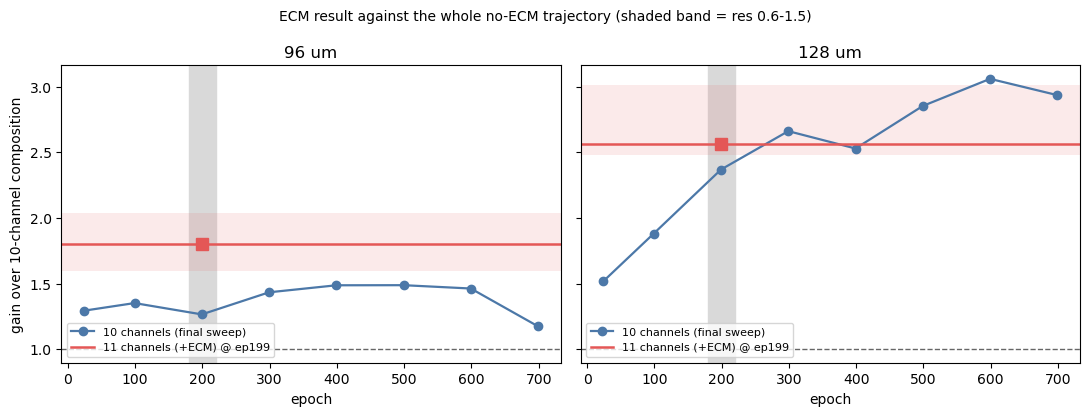

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, fov in zip(axes, (96, 128)):
    t = TRAJ.query("fov == @fov").sort_values("epoch")
    ax.plot(t["epoch"], t["gain"], "o-", color="#4C78A8", lw=1.6, label="10 channels (final sweep)")
    row = HEAD.query("fov == @fov and arm == 'ecm'").iloc[0]
    ax.axhline(row["gain"], color="#E45756", lw=1.8,
               label="11 channels (+ECM) @ ep{}".format(EPOCH))
    ax.plot([EPOCH], [row["gain"]], "s", color="#E45756", ms=8)
    ax.axhspan(row["gain_res_lo"], row["gain_res_hi"], color="#E45756", alpha=0.12, lw=0)
    ax.axhline(1.0, color="0.4", lw=1, ls="--")
    ax.axvspan(180, 220, color="0.85", zorder=0)
    ax.set_xlabel("epoch"); ax.set_title("{} um".format(fov))
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("gain over 10-channel composition")
fig.suptitle("ECM result against the whole no-ECM trajectory (shaded band = res 0.6-1.5)", fontsize=10)
plt.tight_layout(); plt.show()

## 6. Qualitative — do the ECM clusters look like anything?

Same construction as the metrics (SmartPca → SmartUmap → Leiden on the UMAP graph), so
these panels show the exact partitions the numbers above were computed on. The two arms
get **disjoint palettes** (even and odd slices of `glasbey_dark`) so a colour in the
10-channel panel is never the same colour in the 11-channel panel — the cluster IDs are
unrelated between arms.

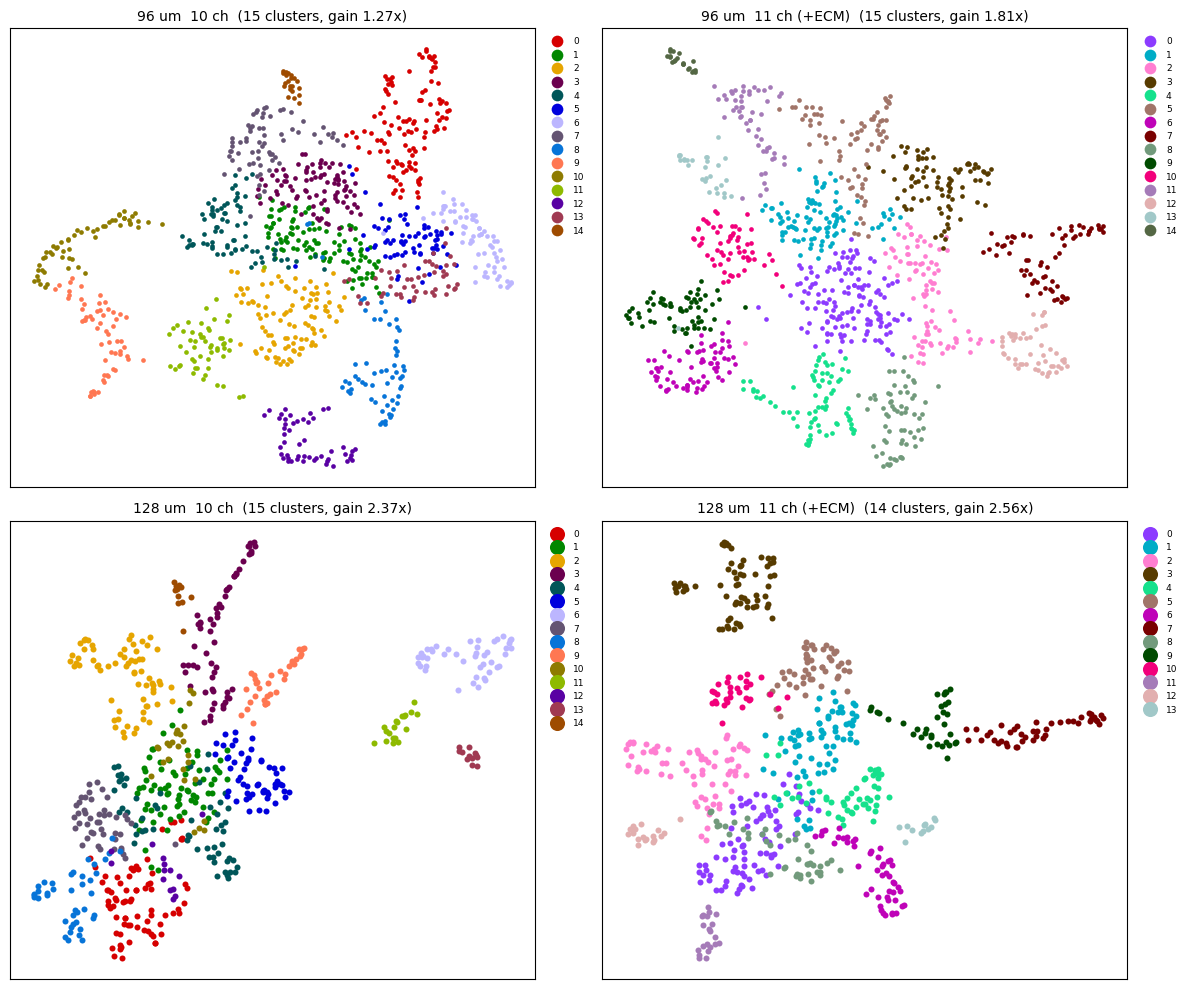

In [12]:
def scatter_umap(ax, xy, labels, pal, title, legend=True, s=None):
    s = s if s is not None else max(3.0, 12000.0 / len(xy))
    for lab in sorted(set(labels.tolist())):
        m = labels == lab
        ax.scatter(xy[m, 0], xy[m, 1], s=s, c=[pal[lab]], label=str(lab), linewidths=0)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title, fontsize=10)
    if legend:
        ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=6.5,
                  markerscale=2.5, frameon=False)

PAL = {}
for fov in (96, 128):
    for arm, off in (("base", 0), ("ecm", 1)):
        lab = LAB[(fov, arm)][(1.0, 0)]
        PAL[(fov, arm)] = imc_tm.cluster_palette(labels=sorted(set(lab.tolist())),
                                                 offset=off, stride=2)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, fov in enumerate((96, 128)):
    for j, arm in enumerate(("base", "ecm")):
        lab = LAB[(fov, arm)][(1.0, 0)]
        g = float(HEAD.query("fov == @fov and arm == @arm")["gain"].iloc[0])
        scatter_umap(axes[i, j], EMB[(fov, arm)]["umap"], lab, PAL[(fov, arm)],
                     "{} um  {}  ({} clusters, gain {:.2f}x)".format(
                         fov, "10 ch" if arm == "base" else "11 ch (+ECM)",
                         len(set(lab.tolist())), g))
plt.tight_layout(); plt.show()

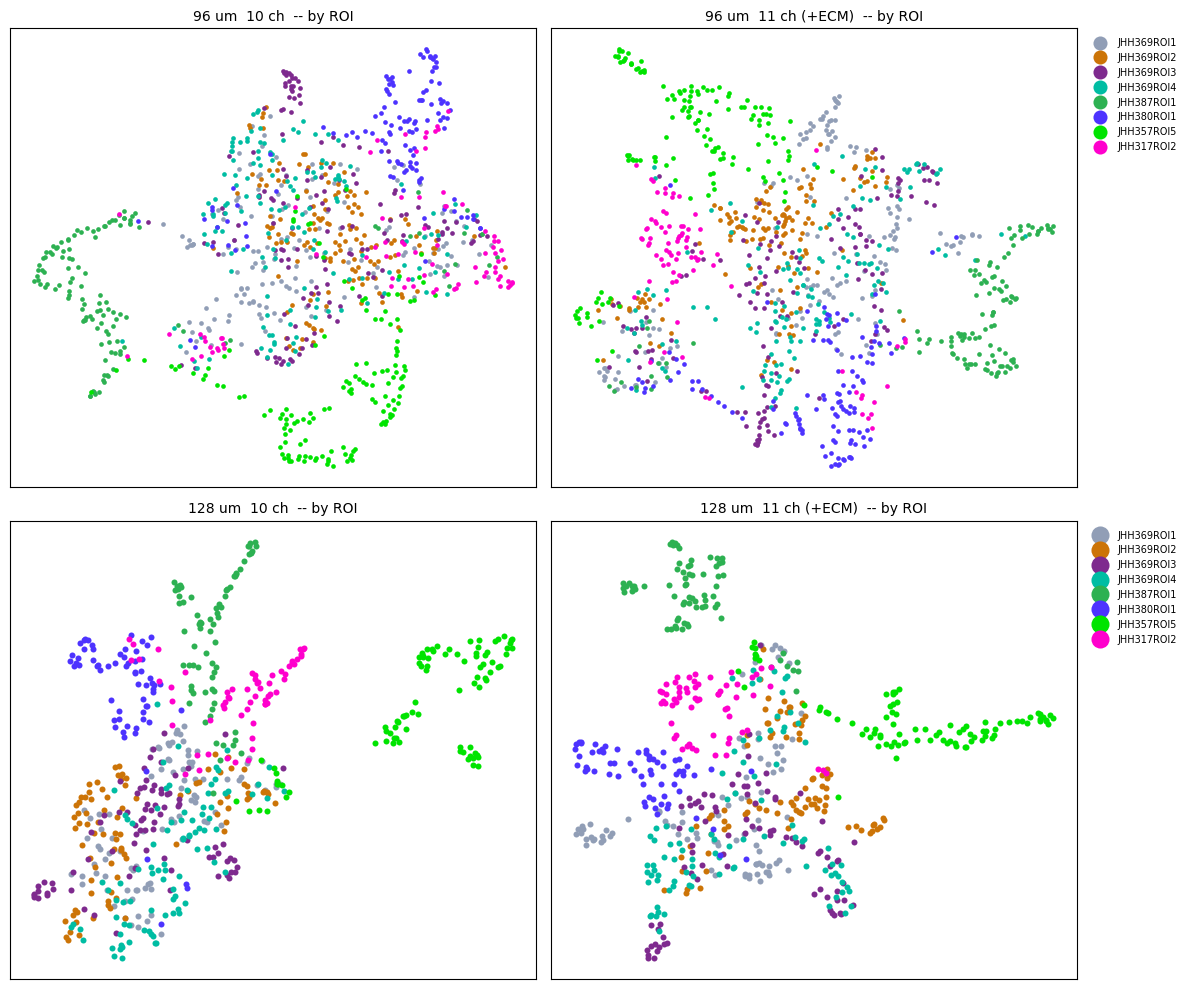

In [13]:
# Same embeddings, coloured by ROI. Clusters that are really ROI identity in disguise
# show up here as one-colour islands.
RPAL = imc_tm.roi_palette(imc_tm.FINAL_ROIS)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, fov in enumerate((96, 128)):
    d = DAT[fov]
    for j, arm in enumerate(("base", "ecm")):
        xy = EMB[(fov, arm)]["umap"]
        s = max(3.0, 12000.0 / len(xy))
        for r in imc_tm.FINAL_ROIS:
            m = d["roi"] == r
            axes[i, j].scatter(xy[m, 0], xy[m, 1], s=s, c=[RPAL[r]], label=r, linewidths=0)
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
        axes[i, j].set_title("{} um  {}  -- by ROI".format(
            fov, "10 ch" if arm == "base" else "11 ch (+ECM)"), fontsize=10)
for ax in (axes[0, 1], axes[1, 1]):
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7, markerscale=3, frameon=False)
plt.tight_layout(); plt.show()

### Tissue maps

Six panels per ROI, all in the raster frame so cells and windows overlay correctly:
measured cell types, the ECM field the 11th channel carries, then the four cluster maps.
Windows are drawn as **true squares in data coordinates**, so contiguous blocks read as
contiguous rather than as a dot grid.

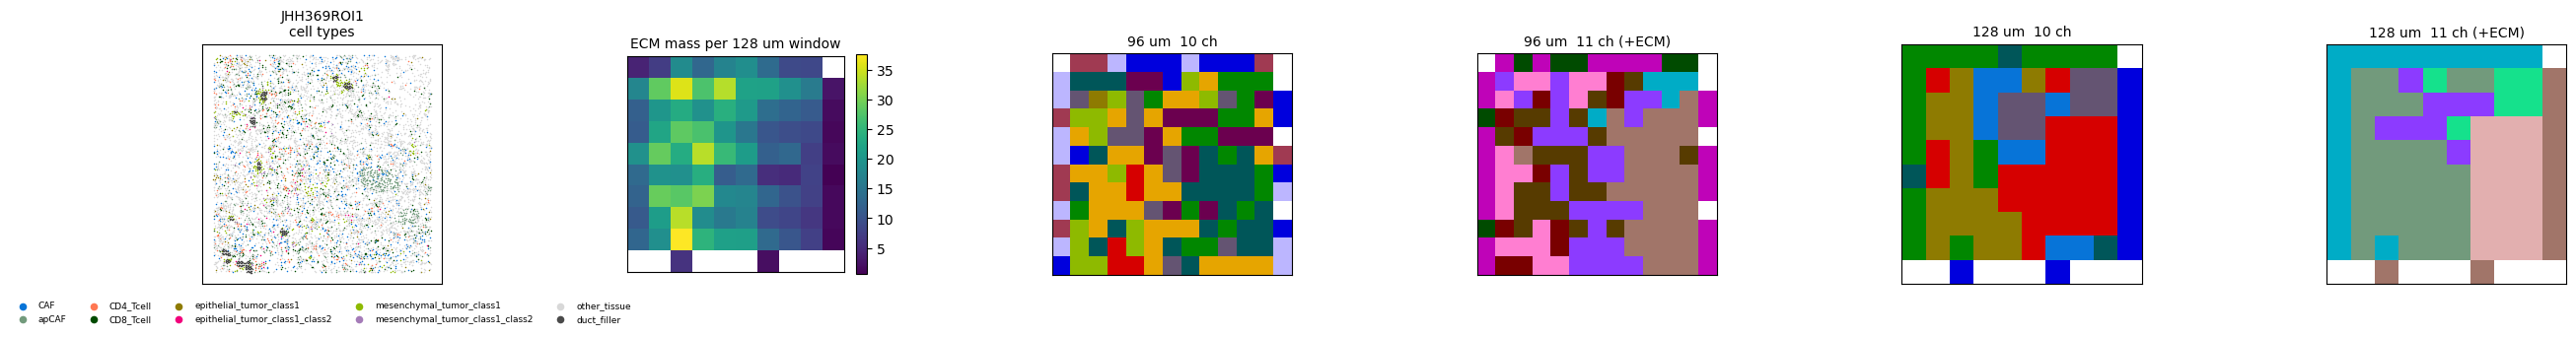

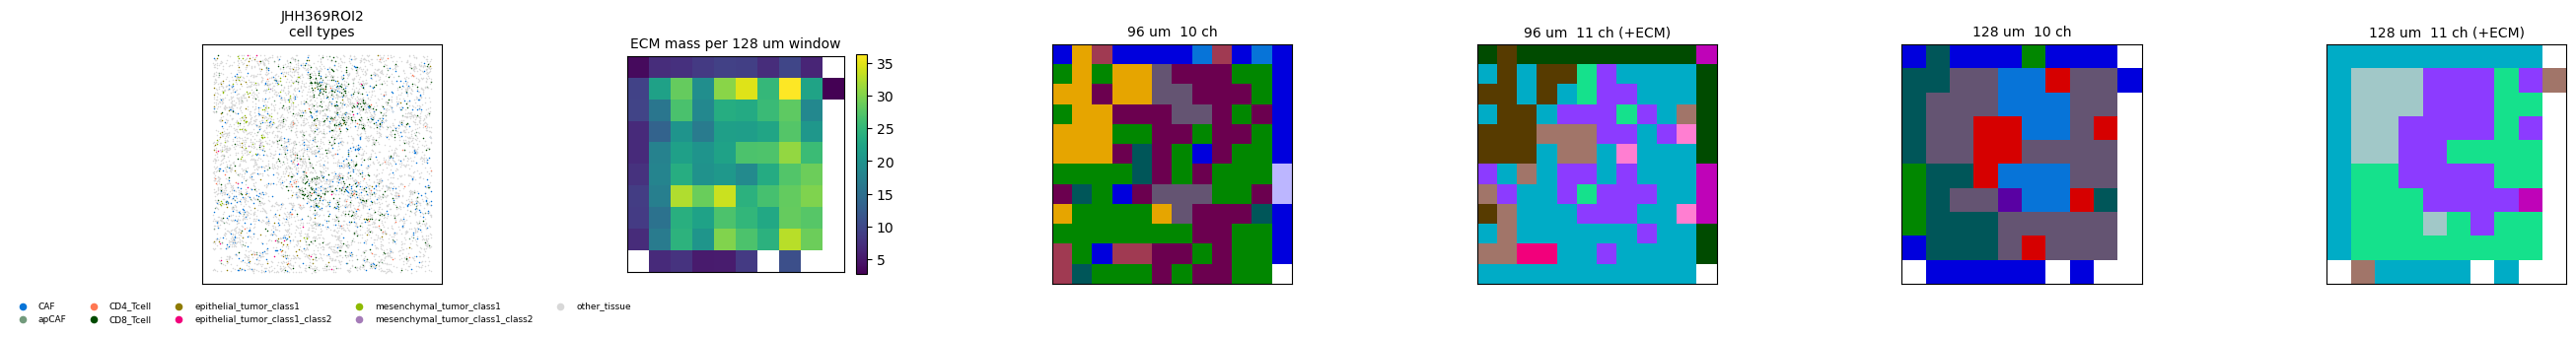

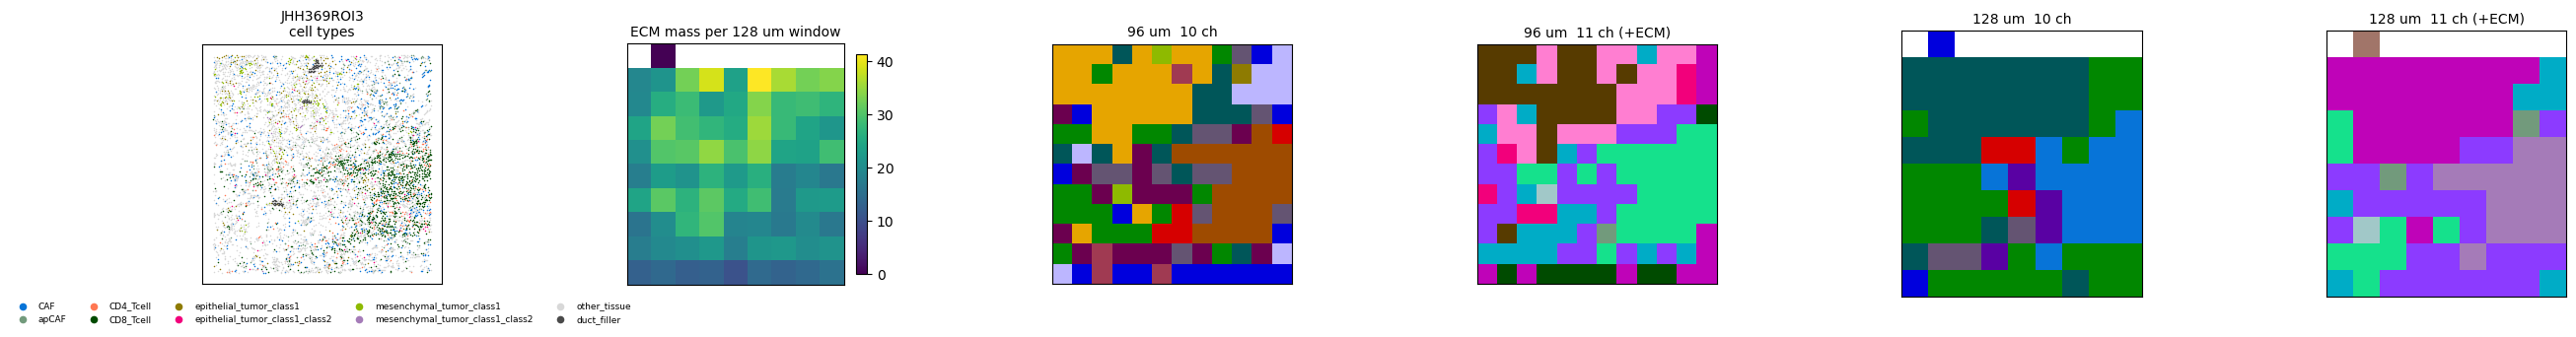

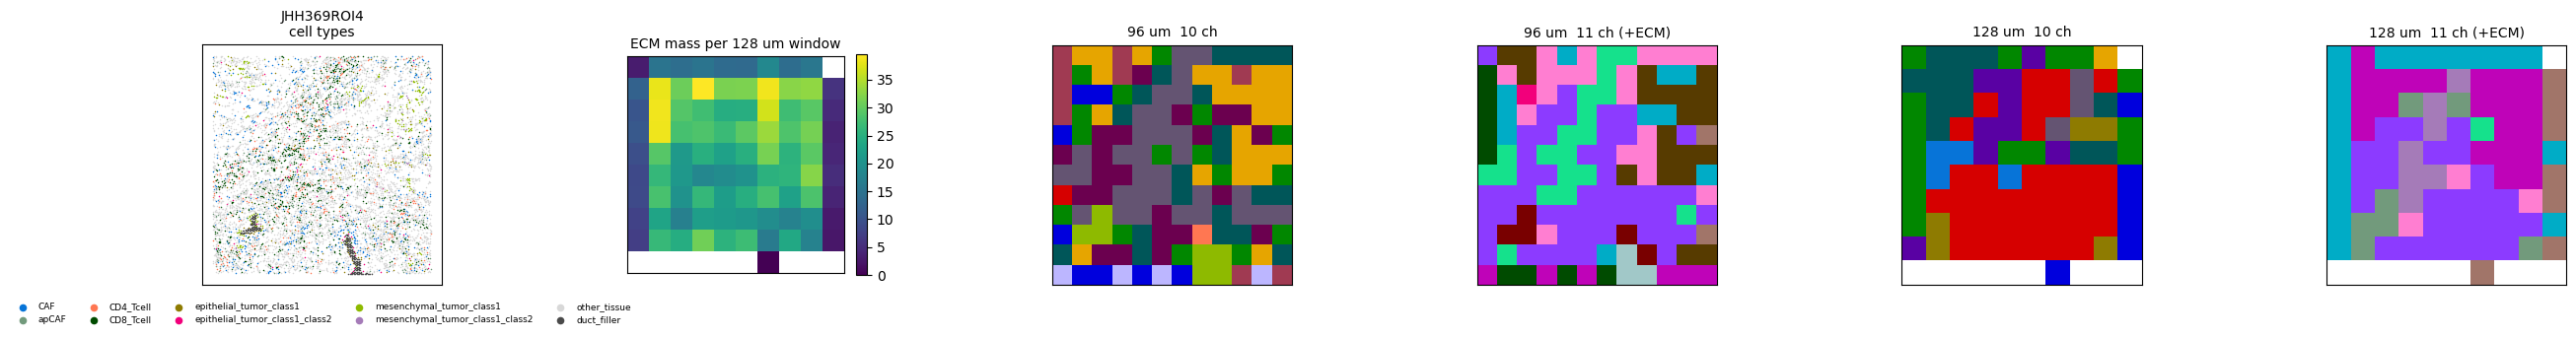

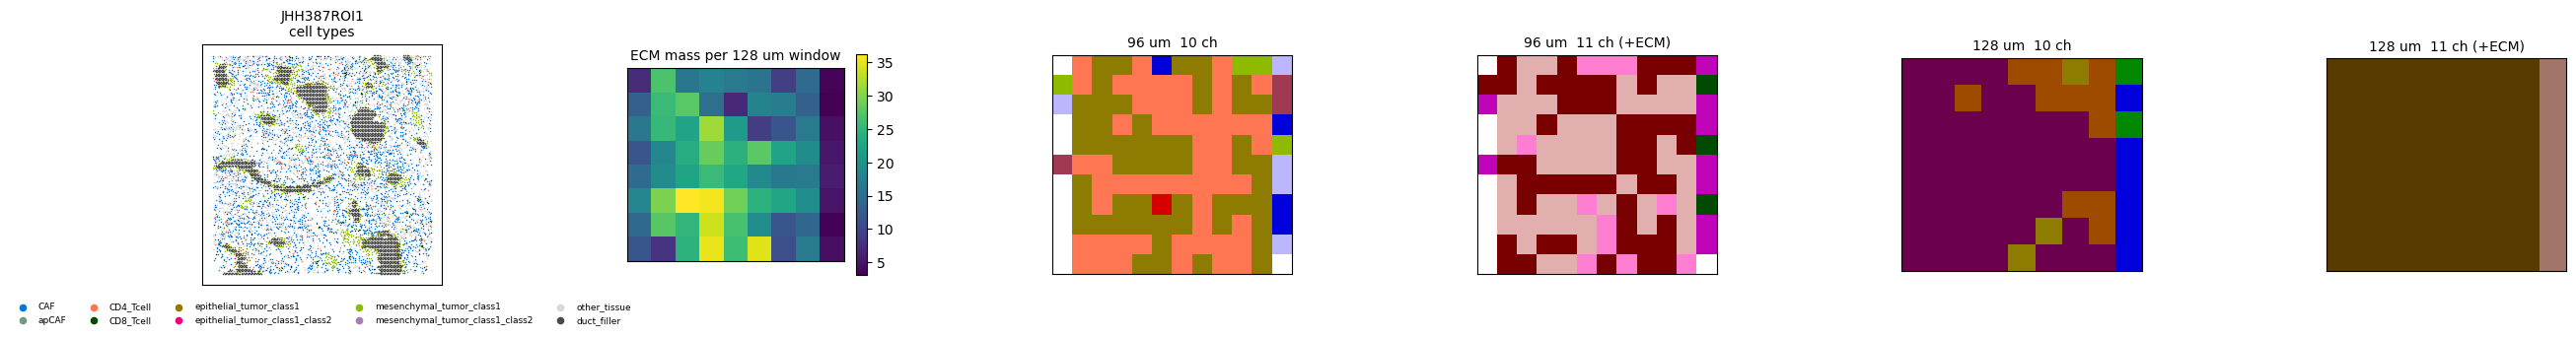

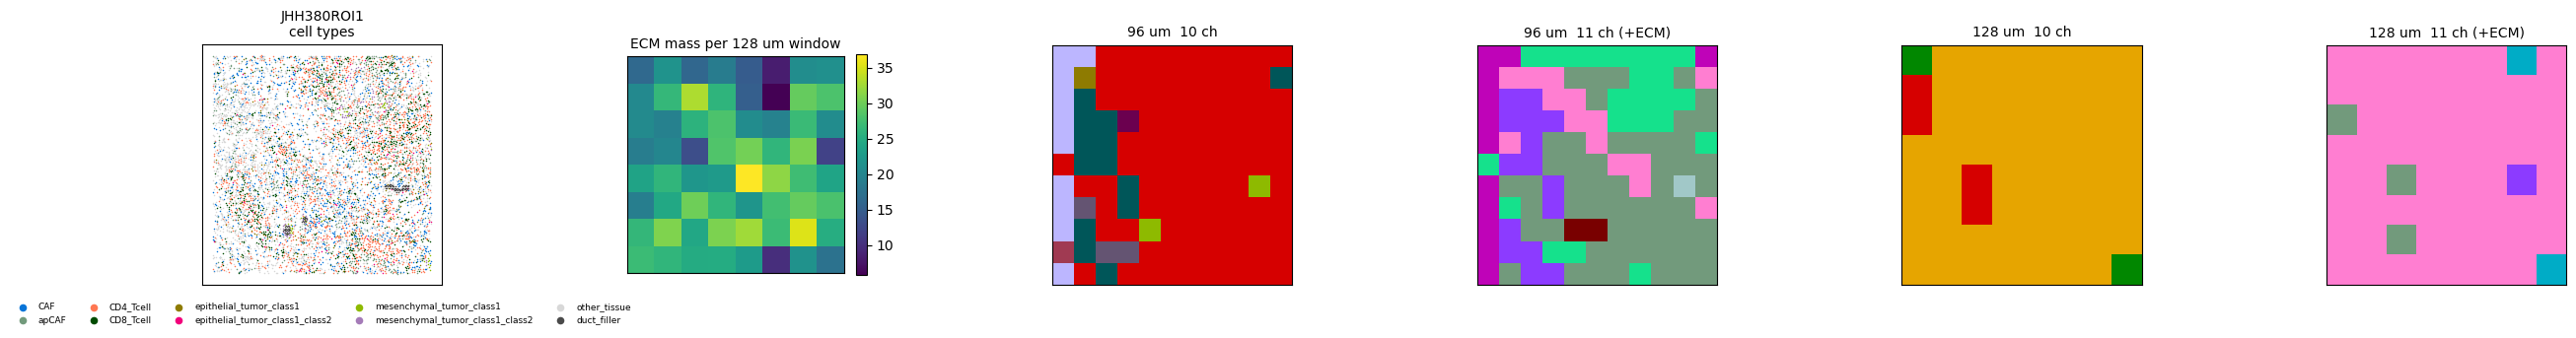

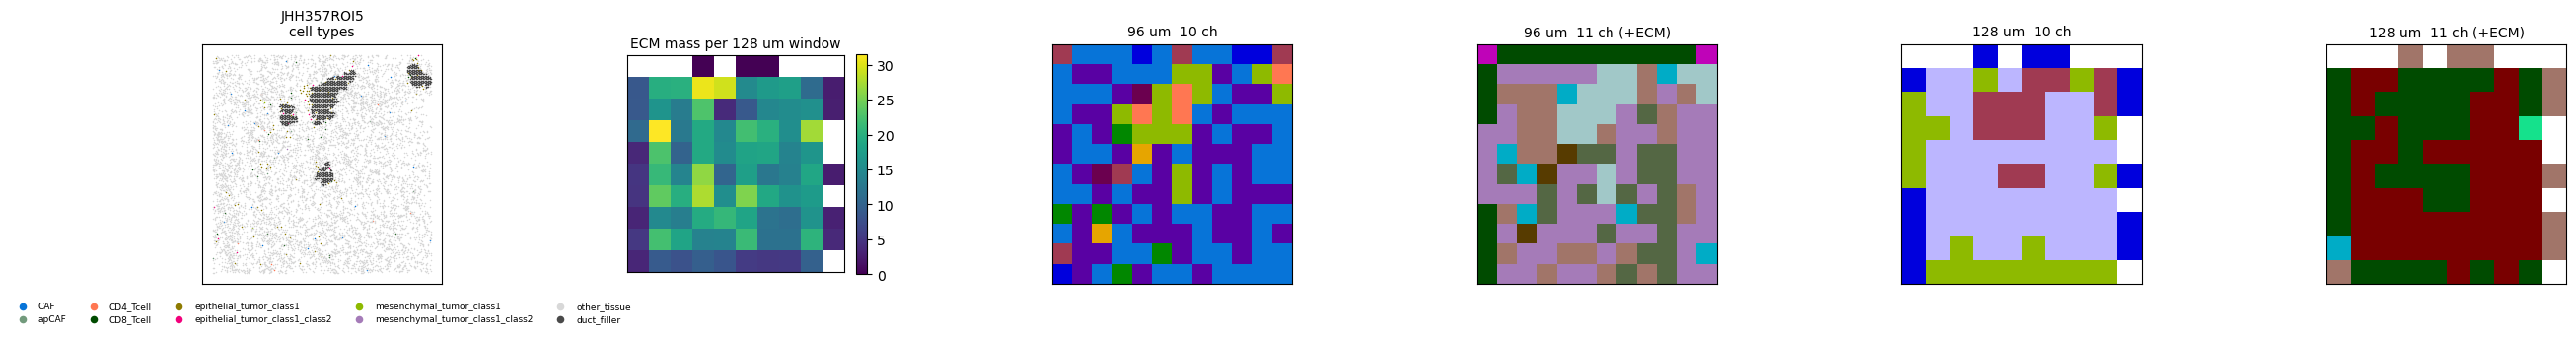

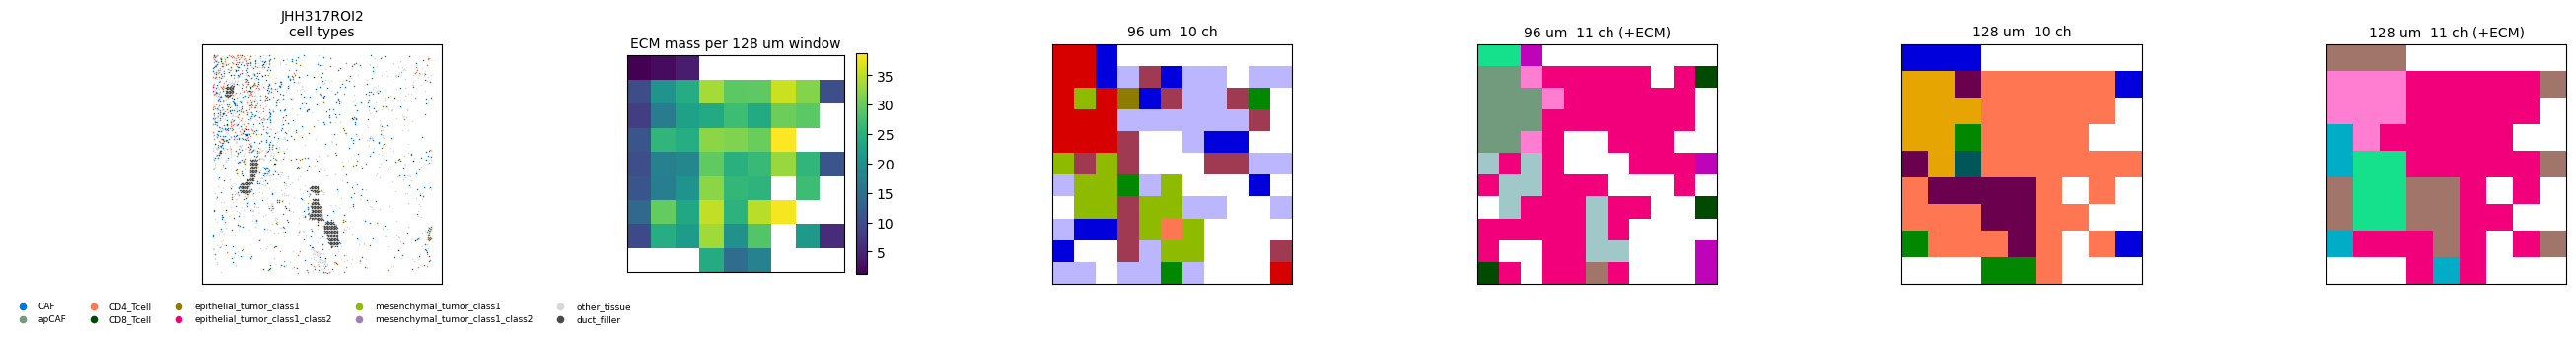

In [14]:
CT_PAL = imc_tm.palette()
for roi in imc_tm.FINAL_ROIS:
    fig, axes = plt.subplots(1, 6, figsize=(26, 4.8))

    a = ad_.read_h5ad(imc_tm.H5AD_DIR / (roi + ".h5ad"))
    cx, cy = imc_tm.raster_frame(a, pixel_size=2.0)
    for t in imc_tm.CELL_TYPES:
        m = (a.obs["cell_type"] == t).values
        if m.sum():
            axes[0].scatter(cx[m], cy[m], s=1.2, c=[CT_PAL[t]], label=t, linewidths=0)
    axes[0].set_aspect("equal"); axes[0].set_title("{}\ncell types".format(roi), fontsize=10)

    d128 = DAT[128]
    m = d128["roi"] == roi
    ecm_v = d128["n_ecm"][m]
    norm = (ecm_v - ecm_v.min()) / max(1e-9, np.ptp(ecm_v))
    imc_tm.plot_window_map(axes[1], d128["centers"][m], plt.cm.viridis(norm), 128)
    sm = plt.cm.ScalarMappable(cmap="viridis",
                               norm=plt.Normalize(ecm_v.min(), ecm_v.max()))
    plt.colorbar(sm, ax=axes[1], fraction=0.046)
    axes[1].set_title("ECM mass per 128 um window", fontsize=10)

    for k, (fov, arm) in enumerate([(96, "base"), (96, "ecm"), (128, "base"), (128, "ecm")]):
        ax = axes[2 + k]
        d = DAT[fov]; mm = d["roi"] == roi
        lab = LAB[(fov, arm)][(1.0, 0)][mm]
        imc_tm.plot_window_map(ax, d["centers"][mm], [PAL[(fov, arm)][l] for l in lab], fov)
        ax.set_title("{} um  {}".format(fov, "10 ch" if arm == "base" else "11 ch (+ECM)"),
                     fontsize=10)

    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    axes[0].legend(bbox_to_anchor=(0.5, -0.04), loc="upper center", ncol=5,
                   fontsize=6.5, markerscale=5, frameon=False)
    plt.tight_layout(); plt.show()

### Is the ECM channel doing anything, or is it decoration?

If the 11-channel model is genuinely using channel 10, its clusters should separate on
matrix content more than the 10-channel model's clusters do — the 10-channel model cannot
see the field at all, so any separation it shows is matrix correlating with cell layout.

**Which "matrix content", though?** Three quantities get that name and they are not the
same, which is worth being explicit about because the first version of this figure used
the wrong one:

| | what it is | what it also tracks |
|---|---|---|
| `n_ecm` | sum of channel-10 values in the window | **window occupancy** — a border window holds fewer 20 µm voxels *and* less total matrix (r = +0.77 with the voxel count) |
| `n_ecm_voxels` | how many ECM voxels the window contains | nothing but geometry — carries no matrix values at all |
| **`ecm_density`** | `n_ecm / n_ecm_voxels` | **the mean matrix value over the tissue covered** — geometry divided out |

All three are plotted. The middle column is the control that makes the point: clusters
separate on **pure occupancy** at η² 0.32–0.66, so a good part of the mass-based number is
the model resolving where the tissue edge is, not how much matrix is there. `ecm_density`
is the honest measure, and the base→ECM comparison survives on it — smaller in absolute
terms, and at 128 µm relatively larger, because the 10-channel model's mass score was
mostly occupancy to begin with.


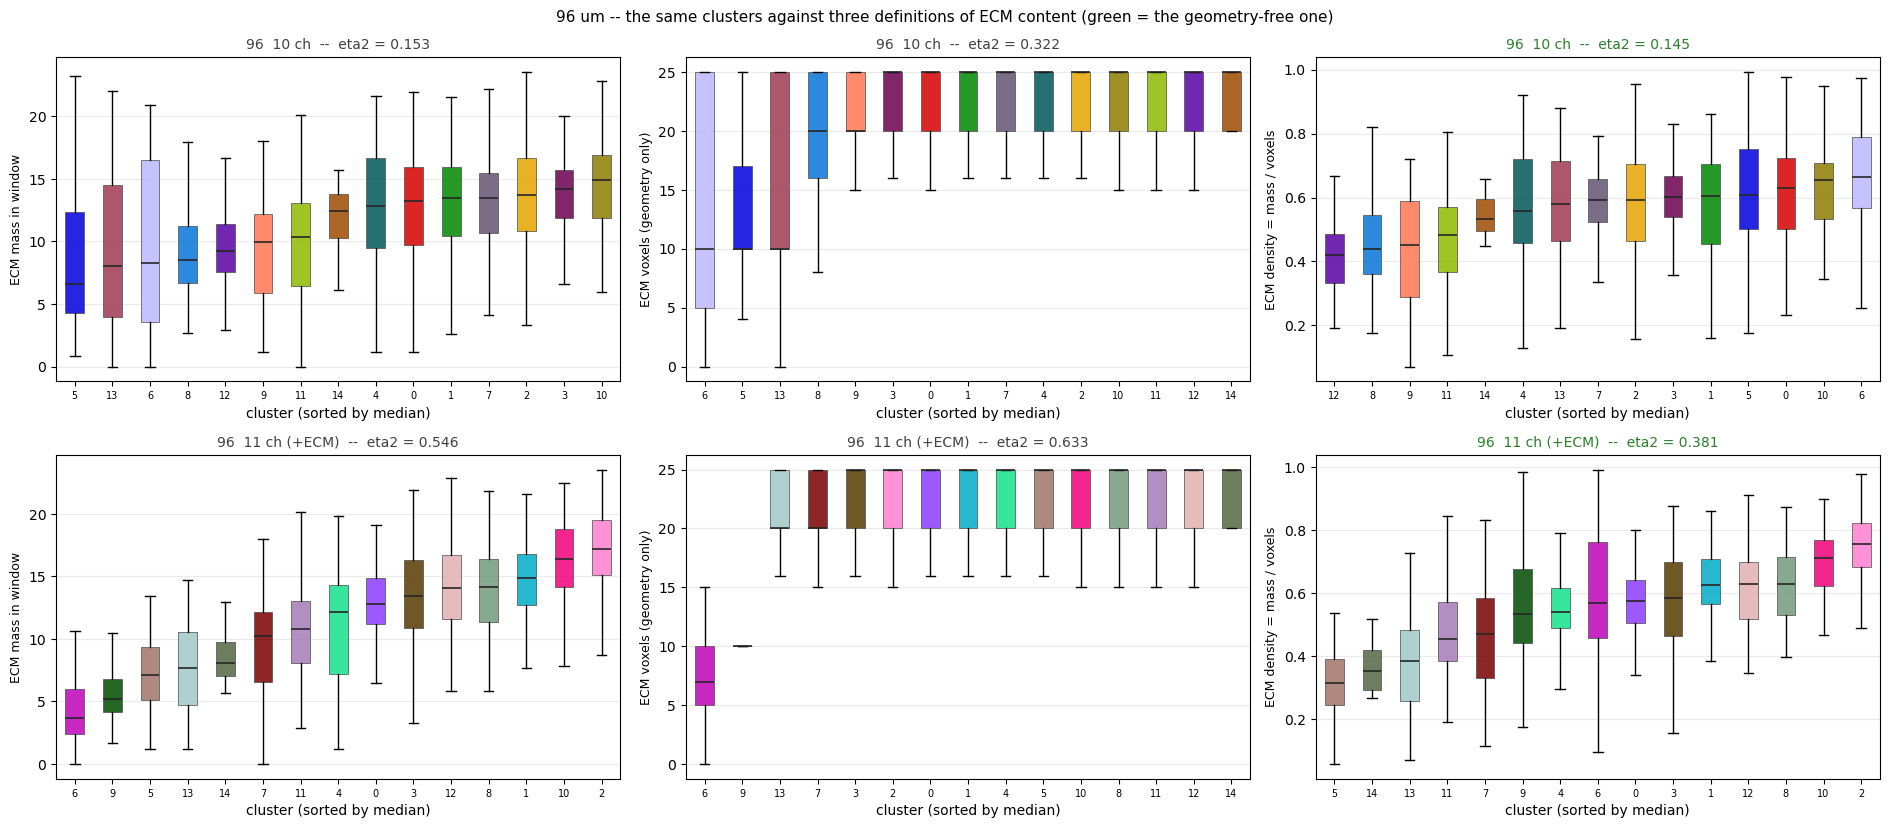

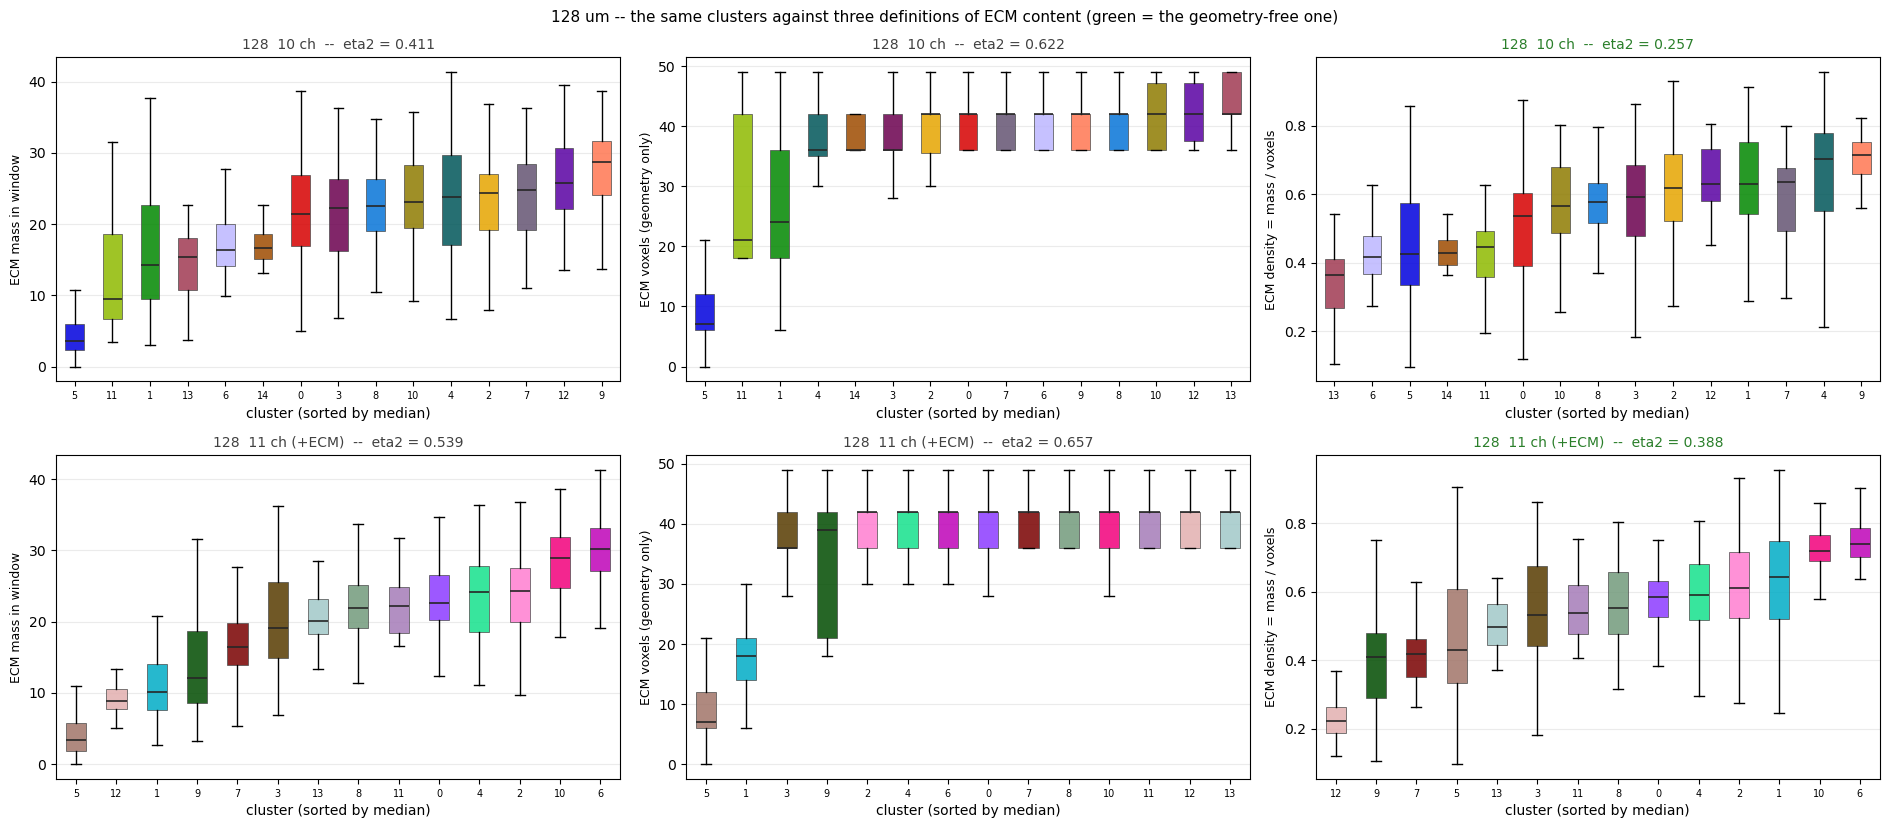

eta2 by measure -- n_ecm_voxels is the control: it contains NO matrix values


measure   n_ecm  n_ecm_voxels  ecm_density
fov arm                                   
96  base  0.153         0.322        0.145
    ecm   0.546         0.633        0.381
128 base  0.411         0.622        0.257
    ecm   0.539         0.657        0.388

fov 96  base -> ecm:  mass 0.153 -> 0.546   |   DENSITY 0.145 -> 0.381  (2.6x)
fov128  base -> ecm:  mass 0.411 -> 0.539   |   DENSITY 0.257 -> 0.388  (1.5x)


In [15]:
MEASURES = [
    ("n_ecm",        "ECM mass in window",       lambda d: d["n_ecm"]),
    ("n_ecm_voxels", "ECM voxels (geometry only)", lambda d: d["n_ecm_voxels"]),
    ("ecm_density",  "ECM density = mass / voxels", lambda d: imc_tm.ecm_density(d)),
]

def eta2(v, lab):
    ok = np.isfinite(v); v, lab = np.asarray(v)[ok], np.asarray(lab)[ok]
    g = v.mean()
    ssb = sum((lab == k).sum() * (v[lab == k].mean() - g) ** 2 for k in np.unique(lab))
    return ssb / ((v - g) ** 2).sum()

summary = []
for fov in (96, 128):
    d = DAT[fov]
    fig, axes = plt.subplots(2, 3, figsize=(19, 8.4))
    for r, arm in enumerate(("base", "ecm")):
        lab = LAB[(fov, arm)][(1.0, 0)]
        keys = sorted(set(lab.tolist()))
        for cix, (key, label, fn) in enumerate(MEASURES):
            ax = axes[r, cix]
            v = np.asarray(fn(d), dtype=float)
            data = [v[(lab == k) & np.isfinite(v)] for k in keys]
            order_ = np.argsort([np.median(x) if len(x) else 0.0 for x in data])
            bp = ax.boxplot([data[o] for o in order_], patch_artist=True, showfliers=False,
                            medianprops=dict(color="0.15", lw=1.2))
            for patch, o in zip(bp["boxes"], order_):
                patch.set_facecolor(PAL[(fov, arm)][keys[o]]); patch.set_alpha(0.85)
                patch.set_edgecolor("0.3"); patch.set_linewidth(0.6)
            ax.set_xticklabels([str(keys[o]) for o in order_], fontsize=7)
            e = eta2(v, lab)
            summary.append(dict(fov=fov, arm=arm, measure=key, eta2=e))
            ax.set_title("{}  {}  --  eta2 = {:.3f}".format(
                fov, "10 ch" if arm == "base" else "11 ch (+ECM)", e),
                fontsize=10, color=("#2a7f2a" if key == "ecm_density" else "0.25"))
            ax.set_xlabel("cluster (sorted by median)"); ax.set_ylabel(label, fontsize=9)
            ax.grid(axis="y", alpha=0.25)
    fig.suptitle("{} um -- the same clusters against three definitions of ECM content "
                 "(green = the geometry-free one)".format(fov), fontsize=11)
    plt.tight_layout(); plt.show()

ETA = pd.DataFrame(summary).pivot(index=["fov", "arm"], columns="measure", values="eta2")
ETA = ETA[[m[0] for m in MEASURES]]
ETA.to_csv(RESULTS / "ecm_eta2.csv")
print("eta2 by measure -- n_ecm_voxels is the control: it contains NO matrix values")
display(ETA.round(3))
for fov in (96, 128):
    b, e = ETA.loc[(fov, "base")], ETA.loc[(fov, "ecm")]
    print("fov{:3d}  base -> ecm:  mass {:.3f} -> {:.3f}   |   DENSITY {:.3f} -> {:.3f}  ({:.1f}x)".format(
        fov, b["n_ecm"], e["n_ecm"], b["ecm_density"], e["ecm_density"],
        e["ecm_density"] / b["ecm_density"]))


## 7. Caveats

- **No matched no-ECM control was trained.** The design was two ECM runs only, so the
  comparison borrows the final sweep's checkpoints. Those share everything except the LR
  protocol — `(0, 100, 900, 1000)` against `(0, 20, 180, 200)` — which is why section 5
  compares against the base model's whole trajectory rather than a single epoch. The clean
  experiment is a 200-epoch 10-channel run on the same schedule:
  `python run_ecm_screen.py --control --parallel`, about 5.5 h.
- **The two arms did not train on the same tiles.** The one-hot branch in
  `CropperSparseTensor` means matrix alone can satisfy `n_element_min_for_crop = 20`, so
  the ECM arm saw emptier tiles than the base arm at threshold 10. Analysis re-filters to
  a shared grid, but *training* exposure differed and this notebook cannot undo that.
- **"ECM content" is three different numbers** (section 6). The first version of this
  notebook scored the channel on total mass, which is partly window occupancy; `eta2` on
  the voxel count alone reaches 0.32-0.66 with no matrix values involved. The conclusion
  holds on the geometry-free measure but the absolute numbers were inflated.
- **`SmartPca` seeds nothing upstream** (section 4). `imc_tm.umap_graph` now seeds around
  it, and section 4 asserts reproducibility, but any TissueMosaic clustering run outside
  this module still carries that variance — including numbers from earlier notebooks
  computed before the fix.
- **ECM normalisation is per-ROI**, to each section's own 95th percentile. Channel 10 is a
  within-section relative density; it carries no cross-section absolute scale, so a
  cluster defined by "high matrix" means high *for its own ROI*.
- **ECM is an initial condition, not a measurement of these cells.** It comes from the
  OME-TIFF upstream of segmentation, which is what keeps the gain metric meaningful — it
  is not a function of the cell-type channels — but it is a modelling input, not an
  orthogonal assay.
- **Eight ROIs, five patients, all training data.** Nothing here is a transfer test. The
  held-out tiers from S2 have not been run for the ECM arm.